# Koopman-MPC Closed-Loop Control

This notebook shows **receding-horizon Koopman-MPC**
(`koopman_graph.mpc.KoopmanMPC`) for constrained reference tracking: a quick
identity-plant solve with box input limits, then matched latent-env returns
versus a heuristic policy and optional PPO (notebook 15 protocol), plus
**conformal constraint tightening** that shrinks first-action magnitude and
peak outputs under `y_max`.

**Prerequisites**

```bash
pip install "koopman-graph[mpc]"          # OSQP — required for solve/rollout
pip install "koopman-graph[rl]"           # optional PPO comparison (stable-baselines3)
```

Without `[mpc]`, solve cells print a skip message rather than raising. CI /
pytest uses a tiny identity plant (same construction as `tests/test_mpc.py`).
Interactive runs optionally fit a controlled IEEE 118 Vm model for the deep
dive (notebook 15 plant story, shorter hyperparameters).


## Setup


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os
import random

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST") or os.environ.get("CI"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.data import Data

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.data import GraphSnapshotSequence
from koopman_graph.mpc import KoopmanMPC
from koopman_graph.uq import ConformalKoopmanUQ
from koopman_graph.uq.common import snapshot_with_features

try:
    import osqp  # noqa: F401

    OSQP_AVAILABLE = True
except ImportError:
    OSQP_AVAILABLE = False

try:
    from stable_baselines3 import PPO

    SB3_AVAILABLE = True
except ImportError:
    SB3_AVAILABLE = False
    PPO = None  # type: ignore[misc, assignment]

IS_TEST = bool(
    os.environ.get("PYTEST_CURRENT_TEST")
    or os.environ.get("CI")
    or os.environ.get("IS_TEST")
)
SEED = 31
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

HORIZON = 4 if IS_TEST else 6
ROLLOUT_STEPS = 8 if IS_TEST else 16
EPOCHS = 2 if IS_TEST else 40
TARGET_VM = 1.0
print(
    f"IS_TEST={IS_TEST}  OSQP={OSQP_AVAILABLE}  SB3={SB3_AVAILABLE}  "
    f"HORIZON={HORIZON}"
)
if not OSQP_AVAILABLE:
    print('Install MPC solver: pip install "koopman-graph[mpc]"')


IS_TEST=False  OSQP=True  SB3=True  HORIZON=6


## Motivation and background

Linear predictors in latent space make quadratic MPC tractable (Korda & Mezić,
*Automatica* 2018 — `Korda2018`). In KoopmanGraph 0.6.0, `KoopmanMPC` supports
**discrete additive** control only. Per-node latents advance as

$$
z_{h+1} = z_h K^{\top} + u_h B
$$

(row form; equivalent column plant $x^{+} = Kx + B^{\top}u$). The QP uses the
**mean** latent over nodes as state and a **global** control
$u \in \mathbb{R}^{c}$, with box input constraints and optional locally
linearized output boxes.

Split conformal half-widths (Lei et al., *JASA* 2018 — `Lei2018`) can
**tighten** those output boxes stage-wise via `constraint_tightening=`
(Liang et al. arXiv:2504.00352 / Chee et al. PMLR 242). Stage 0 (current) is
unshrunk; later stages subtract calibrated margins. Tightening is more
conservative — useful when constraint violations matter more than aggressive
tracking — and inherits exchangeability plus local-linearization caveats.


## Minimal example: input-box MPC on an identity plant

Track a constant reference with box **input** constraints and no output
boxes. The identity plant (fixed $K$, $B$, identity decoder) gives a fast
closed-loop check before the IEEE / baseline deep dive. Skipped with a clear
message when OSQP is not installed.


In [2]:
class _IdentityDecoder(torch.nn.Module):
    def __init__(self, dim: int) -> None:
        super().__init__()
        self.latent_dim = dim
        self.out_channels = dim

    def forward(self, z, edge_index=None, edge_weight=None):
        del edge_index, edge_weight
        return z


def identity_plant_model(
    *,
    latent_dim: int = 2,
    control_dim: int = 1,
) -> GraphKoopmanModel:
    model = GraphKoopmanModel(
        encoder=GNNEncoder(latent_dim, 4, latent_dim, num_layers=1),
        decoder=_IdentityDecoder(latent_dim),
        latent_dim=latent_dim,
        time_step=0.1,
        control_dim=control_dim,
        control_mode="additive",
    )
    with torch.no_grad():
        model.koopman.K.copy_(0.85 * torch.eye(latent_dim))
        assert model.koopman.B is not None
        b = torch.zeros(control_dim, latent_dim)
        b[0, 0] = 1.0
        model.koopman.B.copy_(b)

    def _encode(x_or_data, edge_index=None, edge_weight=None):
        del edge_index, edge_weight
        if isinstance(x_or_data, Data):
            assert x_or_data.x is not None
            return x_or_data.x.clone()
        return x_or_data.clone()

    model.encode = _encode  # type: ignore[method-assign]
    return model


def two_node_origin(latent_dim: int = 2) -> Data:
    return Data(
        x=torch.zeros(2, latent_dim),
        edge_index=torch.tensor([[0, 1], [1, 0]], dtype=torch.long),
    )


def tracking_rmse(traj: list[Data], reference: torch.Tensor) -> float:
    errs = [
        float(torch.mean((snap.x.mean(dim=0) - reference) ** 2).sqrt().item())
        for snap in traj
    ]
    return float(np.mean(errs))


def peak_feature0(traj: list[Data]) -> float:
    return max(float(snap.x.mean(dim=0)[0]) for snap in traj)


identity_model = identity_plant_model()
identity_origin = two_node_origin()
identity_reference = torch.tensor([1.0, 0.0])

mpc_traj: list[Data] = []
mpc_rmse = float("nan")
actions: list[float] = []

if OSQP_AVAILABLE:
    identity_controller = KoopmanMPC(
        identity_model,
        horizon=HORIZON,
        Q=torch.eye(2),
        R=0.05 * torch.eye(1),
        u_min=torch.tensor([-2.0]),
        u_max=torch.tensor([2.0]),
    )
    mpc_traj = identity_controller.rollout(
        identity_origin, identity_reference, steps=ROLLOUT_STEPS
    )
    mpc_rmse = tracking_rmse(mpc_traj, identity_reference)
    u0 = identity_controller.solve(identity_origin, identity_reference)
    actions = [float(u0.reshape(-1)[0])]
    print(f"MPC tracking RMSE (mean over rollout): {mpc_rmse:.4f}")
    print(f"first action u0={actions[0]:.4f}")
    print(
        "final mean features: "
        f"{mpc_traj[-1].x.mean(dim=0).detach().cpu().numpy()}"
    )
else:
    print('Skipping MPC solve — install: pip install "koopman-graph[mpc]"')


MPC tracking RMSE (mean over rollout): 0.0027
first action u0=0.9597
final mean features: [0.9987109 0.       ]


## Progressive deep dive

Build from the identity demo: (1) choose the plant used for matched returns
(identity in CI; optional IEEE 118 Vm when interactive), (2) compare MPC to a
heuristic and short PPO train under the notebook-15 latent-env reward, (3)
contrast plain vs conformal-tightened output boxes.


### Controlled plant for matched-env comparison

CI keeps the identity plant. Interactive runs fit a controlled IEEE 118 Vm
model with load-ramp exposure (notebook 15 protocol, shorter hyperparameters).


In [3]:
if IS_TEST:
    model = identity_model
    origin = identity_origin
    reference = identity_reference
    feature_dim = 2
    control_dim = 1
    DATA_SOURCE = "identity_plant"
    plant_sequence = GraphSnapshotSequence(
        [two_node_origin() for _ in range(ROLLOUT_STEPS + 2)]
    )
else:
    from koopman_graph.datasets import IEEE118DynamicBenchmark

    controlled = IEEE118DynamicBenchmark.generate(
        num_timesteps=32,
        expose_load_ramp_control=True,
        seed=SEED,
    )
    vm_sequence = GraphSnapshotSequence(
        [
            Data(x=snap.x[:, :1], edge_index=snap.edge_index)
            for snap in controlled
        ],
        control_inputs=controlled.control_inputs,
    )
    torch.manual_seed(SEED)
    model = GraphKoopmanModel(
        encoder=GNNEncoder(1, 32, 16, num_layers=2),
        decoder=GNNDecoder(16, 32, 1, num_layers=2),
        latent_dim=16,
        time_step=0.25,
        control_dim=1,
        control_mode="additive",
        koopman_parameterization="lyapunov",
    )
    _ = model.fit(vm_sequence, epochs=EPOCHS, lr=1e-3)
    origin = vm_sequence[0]
    reference = torch.tensor([TARGET_VM])
    feature_dim = 1
    control_dim = 1
    DATA_SOURCE = "ieee118_vm"
    plant_sequence = vm_sequence

print(f"DATA_SOURCE={DATA_SOURCE}  F={feature_dim}  C={control_dim}")
print(f"OSQP available for solve: {OSQP_AVAILABLE}")


DATA_SOURCE=ieee118_vm  F=1  C=1
OSQP available for solve: True


### Baseline comparison: heuristic and optional PPO

Matched metric with notebook 15: **episode return** under the same latent
Gymnasium reward (−feature-0 MSE vs the reference) and horizon. That reward is
**not** the MPC quadratic cost: `KoopmanMPC` optimizes a mean-latent QP with
local decoder linearization, then the env scores decoded feature-0 error. On a
short-fit IEEE plant the two can disagree — treat the bar chart as a protocol
smoke test, not a claim that the MPC API is mis-implemented. PPO trains only
when `[rl]` is installed (short timesteps — not a tuned baseline).


In [4]:
def tracking_reward(snapshot: Data, step_index: int) -> float:
    del step_index
    # Feature-0 MSE vs reference[0] — matched objective for MPC / heuristic / PPO.
    err = snapshot.x.mean(dim=0)[0] - reference[0]
    return float(-(err ** 2).item())


def rollout_policy(env, policy_fn, seed: int = SEED):
    """Roll out a policy; return decoded feature-0 means and per-step rewards."""
    obs, info = env.reset(seed=seed)
    means = [float(np.mean(info["decoded_x"][:, 0]))]
    rewards = []
    done = False
    step_idx = 0
    while not done:
        action = policy_fn(info["decoded_x"], step_idx, obs)
        obs, reward, terminated, truncated, info = env.step(action)
        means.append(float(np.mean(info["decoded_x"][:, 0])))
        rewards.append(float(reward))
        step_idx += 1
        done = bool(terminated or truncated)
    return np.asarray(means), np.asarray(rewards)


def heuristic_policy(decoded_x, _step, _obs):
    err = float(reference[0] - np.mean(decoded_x[:, 0]))
    return np.array([np.clip(0.5 * err, -1.0, 1.0)], dtype=np.float32)


def make_mpc_policy(controller: "KoopmanMPC"):
    def mpc_policy(decoded_x, _step, _obs):
        snap = Data(
            x=torch.as_tensor(decoded_x, dtype=torch.float32),
            edge_index=origin.edge_index,
        )
        try:
            u = controller.solve(snap, reference)
            return u.detach().cpu().numpy().astype(np.float32).reshape(-1)
        except RuntimeError:
            return np.zeros(control_dim, dtype=np.float32)

    return mpc_policy


env_returns = {
    "mpc": float("nan"),
    "heuristic": float("nan"),
    "ppo": float("nan"),
}
mean_feat = {"mpc": None, "heuristic": None, "ppo": None}

try:
    from koopman_graph.env import GraphKoopmanEnv  # noqa: F401

    RL_ENV_OK = True
except ImportError:
    RL_ENV_OK = False

if RL_ENV_OK and OSQP_AVAILABLE:
    eval_env = model.to_latent_env(
        plant_sequence,
        tracking_reward,
        max_episode_steps=ROLLOUT_STEPS,
        random_start=False,
        start_index=0,
        control_low=-1.0 if not IS_TEST else -2.0,
        control_high=1.0 if not IS_TEST else 2.0,
    )
    mpc_ctrl = KoopmanMPC(
        model,
        horizon=HORIZON,
        Q=torch.eye(feature_dim),
        R=(0.05 if IS_TEST else 0.1) * torch.eye(control_dim),
        u_min=torch.full((control_dim,), -2.0 if IS_TEST else -1.0),
        u_max=torch.full((control_dim,), 2.0 if IS_TEST else 1.0),
    )
    mean_feat["mpc"], r_mpc = rollout_policy(
        eval_env, make_mpc_policy(mpc_ctrl)
    )
    env_returns["mpc"] = float(r_mpc.sum())
    mean_feat["heuristic"], r_heur = rollout_policy(
        eval_env, heuristic_policy
    )
    env_returns["heuristic"] = float(r_heur.sum())
    print(
        f"episode return — MPC={env_returns['mpc']:.4f}  "
        f"heuristic={env_returns['heuristic']:.4f}"
    )
    print(
        f"end mean feature-0 — MPC={mean_feat['mpc'][-1]:.4f}  "
        f"heuristic={mean_feat['heuristic'][-1]:.4f}"
    )
elif not RL_ENV_OK:
    print(
        'Latent env unavailable — install: pip install "koopman-graph[rl]"'
    )
else:
    print(
        "Matched env comparison skipped (OSQP unavailable for MPC policy)."
    )


episode return — MPC=-1.0887  heuristic=-0.2082
end mean feature-0 — MPC=1.3842  heuristic=0.9216


In [5]:
# Optional short PPO on the same reward / horizon (smoke only).
if SB3_AVAILABLE and RL_ENV_OK:
    train_env = model.to_latent_env(
        plant_sequence,
        tracking_reward,
        max_episode_steps=ROLLOUT_STEPS,
        random_start=True,
        control_low=-1.0 if not IS_TEST else -2.0,
        control_high=1.0 if not IS_TEST else 2.0,
    )
    total_ts = 512 if IS_TEST else 2000
    ppo = PPO(
        "MlpPolicy",
        train_env,
        verbose=0,
        n_steps=64 if IS_TEST else 128,
        batch_size=32 if IS_TEST else 64,
        learning_rate=3e-4,
        seed=SEED,
    )
    ppo.learn(total_timesteps=total_ts)
    eval_env = model.to_latent_env(
        plant_sequence,
        tracking_reward,
        max_episode_steps=ROLLOUT_STEPS,
        random_start=False,
        start_index=0,
        control_low=-1.0 if not IS_TEST else -2.0,
        control_high=1.0 if not IS_TEST else 2.0,
    )

    def ppo_policy(_decoded, _step, obs):
        action, _ = ppo.predict(obs, deterministic=True)
        return np.asarray(action, dtype=np.float32).reshape(-1)

    mean_feat["ppo"], r_ppo = rollout_policy(eval_env, ppo_policy)
    env_returns["ppo"] = float(r_ppo.sum())
    print(
        f"episode return — PPO={env_returns['ppo']:.4f}  "
        f"(short train, {total_ts} timesteps; not a published baseline)"
    )
elif not SB3_AVAILABLE:
    print('PPO comparison skipped — install: pip install "koopman-graph[rl]"')

print(
    "Matched metric summary (episode return; higher is better): "
    f"MPC={env_returns['mpc']}  heuristic={env_returns['heuristic']}  "
    f"PPO={env_returns['ppo']}"
)


episode return — PPO=-0.7522  (short train, 2000 timesteps; not a published baseline)
Matched metric summary (episode return; higher is better): MPC=-1.0886662901611999  heuristic=-0.20816299365833402  PPO=-0.7521730649386882


### Conformal-tightened vs plain MPC

Calibrate split conformal on synthetic residual sequences (identity plant with
a patched zero predictor in CI; IEEE windows plus matching load-ramp controls
when interactive), then compare controllers under a shared `y_max`. CI reports
first-action magnitude **and** peak feature-0; the interactive IEEE branch
prints first `|u|` only. When OSQP is available, the tightened QP should be
more conservative.


In [6]:
def patch_zero_predict(model: GraphKoopmanModel) -> None:
    def _predict(
        initial_graph,
        steps,
        edge_index=None,
        edge_weight=None,
        controls=None,
        future_topologies=None,
        history=None,
    ):
        del edge_weight, controls, future_topologies, history
        if isinstance(initial_graph, Data):
            template = initial_graph
            assert template.x is not None
            zeros = torch.zeros_like(template.x)
        else:
            template = Data(x=initial_graph, edge_index=edge_index)
            zeros = torch.zeros_like(initial_graph)
        return [
            snapshot_with_features(template, zeros) for _ in range(steps)
        ]

    model.predict = _predict  # type: ignore[method-assign]


def constant_residual_cal_sequences(
    model: GraphKoopmanModel,
    *,
    residual: float,
    steps: int,
    n: int,
) -> list[GraphSnapshotSequence]:
    edge_index = two_node_origin().edge_index
    f = model.latent_dim
    sequences: list[GraphSnapshotSequence] = []
    for _ in range(n):
        origin_snap = Data(x=torch.zeros(2, f), edge_index=edge_index)
        snaps = [origin_snap]
        for _h in range(steps):
            snaps.append(
                Data(
                    x=torch.full((2, f), residual),
                    edge_index=edge_index,
                )
            )
        sequences.append(GraphSnapshotSequence(snaps))
    return sequences


tight_demo = {
    "plain_u": float("nan"),
    "tight_u": float("nan"),
    "plain_peak": float("nan"),
    "tight_peak": float("nan"),
}

if OSQP_AVAILABLE and IS_TEST:
    plant = identity_plant_model()
    patch_zero_predict(plant)
    cal = constant_residual_cal_sequences(
        plant, residual=0.25, steps=HORIZON, n=12
    )
    uq = ConformalKoopmanUQ(plant, method="split", score="aggregate")
    uq.calibrate(cal, steps=HORIZON, alpha=0.1)

    y_max = torch.tensor([0.9, 10.0])
    common = dict(
        horizon=HORIZON,
        Q=torch.eye(2),
        R=1e-3 * torch.eye(1),
        u_min=torch.tensor([-2.0]),
        u_max=torch.tensor([2.0]),
        y_max=y_max,
    )
    plain = KoopmanMPC(plant, **common)
    tight = KoopmanMPC(plant, constraint_tightening=uq, **common)
    ref = torch.tensor([2.0, 0.0])
    start = two_node_origin()
    u_plain = plain.solve(start, ref)
    u_tight = tight.solve(start, ref)
    tight_demo["plain_u"] = float(u_plain.abs().sum())
    tight_demo["tight_u"] = float(u_tight.abs().sum())

    def _safe_rollout(ctrl: KoopmanMPC) -> list[Data]:
        current = start
        traj: list[Data] = []
        for _ in range(ROLLOUT_STEPS):
            try:
                action = ctrl.solve(current, ref)
            except RuntimeError:
                break
            with torch.no_grad():
                z = plant.encode(current)
                z_next = plant.koopman.advance(z, control=action)
                decoded = plant.decoder(z_next, current.edge_index)
            current = Data(x=decoded, edge_index=current.edge_index)
            traj.append(current)
        return traj

    plain_traj = _safe_rollout(plain)
    tight_traj = _safe_rollout(tight)
    if plain_traj and tight_traj:
        tight_demo["plain_peak"] = peak_feature0(plain_traj)
        tight_demo["tight_peak"] = peak_feature0(tight_traj)

    print(
        f"first |u|  plain={tight_demo['plain_u']:.4f}  "
        f"tight={tight_demo['tight_u']:.4f}"
    )
    print(
        f"peak feature-0  plain={tight_demo['plain_peak']:.4f}  "
        f"tight={tight_demo['tight_peak']:.4f}"
    )
    print(
        "Expect tightened |u| and peak ≤ plain (more conservative margins)."
    )
elif OSQP_AVAILABLE and not IS_TEST:
    # Controlled models require future u for predict-based conformal scores.
    cal_windows: list[GraphSnapshotSequence] = []
    cal_controls: list[list[torch.Tensor]] = []
    steps = HORIZON
    u_seq = plant_sequence.control_inputs
    for t in range(0, max(1, plant_sequence.num_timesteps - steps - 1), 2):
        snaps = [plant_sequence[t + k] for k in range(steps + 1)]
        cal_windows.append(GraphSnapshotSequence(snaps))
        if u_seq is None:
            cal_controls.append(
                [torch.zeros(control_dim) for _ in range(steps)]
            )
        else:
            cal_controls.append([u_seq[t + k] for k in range(steps)])
    if len(cal_windows) < 4:
        print("Not enough IEEE windows for conformal demo; skipping.")
    else:
        uq = ConformalKoopmanUQ(model, method="split", score="aggregate")
        uq.calibrate(
            cal_windows[:16],
            steps=steps,
            alpha=0.2,
            controls=cal_controls[:16],
        )
        # Soft Vm box just above the current decode peak keeps the plain QP
        # feasible; conformal margins then shrink later stages.
        with torch.no_grad():
            z0 = model.encode(origin)
            y_peak = float(
                model.decoder(z0, origin.edge_index).max().item()
            )
        y_max = torch.tensor([max(1.2, y_peak + 0.02)])
        common = dict(
            horizon=HORIZON,
            Q=torch.eye(1),
            R=0.1 * torch.eye(1),
            u_min=torch.tensor([-1.0]),
            u_max=torch.tensor([1.0]),
            y_max=y_max,
        )
        plain = KoopmanMPC(model, **common)
        tight = KoopmanMPC(model, constraint_tightening=uq, **common)
        try:
            u_plain = plain.solve(origin, reference)
            u_tight = tight.solve(origin, reference)
        except RuntimeError as exc:
            print(f"IEEE tightening solve skipped ({exc}).")
        else:
            tight_demo["plain_u"] = float(u_plain.abs().sum())
            tight_demo["tight_u"] = float(u_tight.abs().sum())
            print(
                f"IEEE y_max={float(y_max[0]):.3f}  first |u|  "
                f"plain={tight_demo['plain_u']:.4f}  "
                f"tight={tight_demo['tight_u']:.4f}"
            )
else:
    print("Tightening demo skipped (OSQP unavailable).")


IEEE y_max=1.415  first |u|  plain=0.7384  tight=0.0842


## Results

When OSQP is installed, the left panel is matched latent-env **episode return**
(higher is better) on whichever plant `DATA_SOURCE` names (title annotated).

- **Identity (`identity_plant`, CI):** expect MPC ≥ heuristic — the QP plant
  matches the env.
- **IEEE (`ieee118_vm`, interactive):** ranking is a smoke comparison only;
  short-fit model mismatch often puts the heuristic (or even short PPO) above
  MPC on this reward. Read the printed end feature-0 means for overshoot.

The right panel is always the **identity-plant** MPC rollout of mean feature-0
toward the reference (fast approach, small steady-state gap from input cost).
If conformal tightening ran, the second figure compares first-action
magnitudes — tightened should be smaller. Without `[mpc]`, figures skip and
the printed messages are the record of the run.


Return ranking on ieee118_vm (smoke only; mismatch common): heuristic=-0.2082 > PPO=-0.7522 > MPC=-1.0887


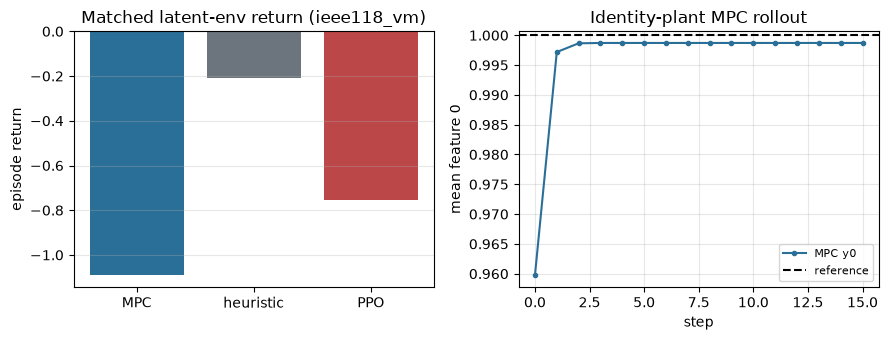

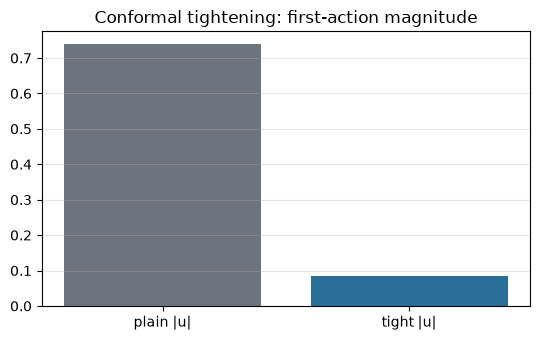

Tightening check: tight |u| ≤ plain |u| (0.0842 ≤ 0.7384).


In [7]:
labels = ["MPC", "heuristic"]
vals = [env_returns["mpc"], env_returns["heuristic"]]
if not np.isnan(env_returns["ppo"]):
    labels.append("PPO")
    vals.append(env_returns["ppo"])
colors = ["#2a6f97", "#6c757d", "#bc4749"][: len(labels)]

# Plant-aware ranking note (stdout aligns with Results markdown).
if not any(np.isnan(v) for v in vals[:2]):
    ranking = sorted(
        zip(labels[: len(vals)], vals, strict=True),
        key=lambda kv: kv[1],
        reverse=True,
    )
    order = " > ".join(f"{name}={ret:.4f}" for name, ret in ranking)
    if DATA_SOURCE == "identity_plant":
        print(f"Return ranking on {DATA_SOURCE} (expect MPC ≥ heuristic): {order}")
    else:
        print(
            f"Return ranking on {DATA_SOURCE} (smoke only; mismatch common): "
            f"{order}"
        )

if OSQP_AVAILABLE and mpc_traj:
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    if not any(np.isnan(v) for v in vals[:2]):
        axes[0].bar(labels, vals, color=colors)
        axes[0].set_ylabel("episode return")
        axes[0].set_title(f"Matched latent-env return ({DATA_SOURCE})")
    else:
        axes[0].text(
            0.5, 0.5, "env returns unavailable", ha="center", va="center"
        )
        axes[0].set_axis_off()
    axes[0].grid(axis="y", alpha=0.3)

    series = [float(s.x.mean(dim=0)[0]) for s in mpc_traj]
    axes[1].plot(series, marker="o", ms=3, color="#2a6f97", label="MPC y0")
    axes[1].axhline(
        float(identity_reference[0]), color="k", ls="--", label="reference"
    )
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("mean feature 0")
    axes[1].set_title("Identity-plant MPC rollout")
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print("Plot skipped (no MPC trajectory — install koopman-graph[mpc]).")

if OSQP_AVAILABLE and not np.isnan(tight_demo["plain_u"]):
    fig, ax = plt.subplots(figsize=(5.5, 3.5))
    ax.bar(
        ["plain |u|", "tight |u|"],
        [tight_demo["plain_u"], tight_demo["tight_u"]],
        color=["#6c757d", "#2a6f97"],
    )
    ax.set_title("Conformal tightening: first-action magnitude")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()
    if tight_demo["tight_u"] <= tight_demo["plain_u"]:
        print(
            "Tightening check: tight |u| ≤ plain |u| "
            f"({tight_demo['tight_u']:.4f} ≤ {tight_demo['plain_u']:.4f})."
        )


## Interpretation

- **Additive latent MPC** is a linear QP on the mean-latent plant
  $(K, B^{\top})$ — not a claim of global optimality for the nonlinear
  decoded plant, and not a substitute for grid OPF.
- **Identity vs IEEE returns.** On the identity plant, MPC and the env share
  the same linear map, so MPC typically wins the matched return. On IEEE, a
  short-fit Koopman model plus mean-latent / linearization mismatch can make
  MPC **worse** than a simple proportional heuristic on decoded feature-0 MSE
  (and can overshoot the Vm reference) even while the identity rollout still
  looks clean. That is plant/model error, not an OSQP failure.
- **Output boxes** use a local decoder linearization; guarantees are local.
- **Tightening** shrinks `y_min`/`y_max` by conformal half-widths per stage
  (stage 0 unshrunk). Expect smaller first `|u|` (and lower peak feature-0 in
  the CI identity demo), not better tracking RMSE.
- **PPO** optimizes the same Gym reward as the heuristic, not the MPC QP.
  With a short train it may land between heuristic and MPC, beat MPC on a
  mismatched plant, or lose to both — treat it as a smoke baseline only
  (notebook 15).


## Takeaways

- Use `KoopmanMPC` when you have a discrete additive controlled Koopman model
  and need constrained reference tracking (`pip install "koopman-graph[mpc]"`).
- Pass a calibrated `ConformalKoopmanUQ` as `constraint_tightening=` when
  constraint satisfaction matters more than aggressive tracking.
- Prefer MPC for explicit constraints and quadratic costs (`Korda2018`); prefer
  PPO / RL when the objective is a non-quadratic Gym reward (notebook 15).
- When **not** to read the IEEE return bar as a verdict: short-fit learned
  plants, reward–QP mismatch, or decoded overshoot — validate the model first
  (identity demo / open-loop residuals) before blaming the controller.
- The minimal demo is always the identity plant; CI matched returns stay on
  that plant, while interactive runs may use IEEE 118 Vm for the deep dive.
- Gotcha: without OSQP, solve/rollout cells skip — install `[mpc]` before
  treating empty plots as negative evidence.


## Further reading

- API:
  [`koopman_graph.mpc.KoopmanMPC`](https://koopmangraph.readthedocs.io/en/latest/api.html),
  [`GraphKoopmanModel.to_latent_env`](https://koopmangraph.readthedocs.io/en/latest/api.html),
  [`ConformalKoopmanUQ`](https://koopmangraph.readthedocs.io/en/latest/api.html)
- Related notebooks:
  [`15_closed_loop_voltage_control_rl.ipynb`](15_closed_loop_voltage_control_rl.ipynb),
  [`30_conformal_uncertainty.ipynb`](30_conformal_uncertainty.ipynb)
- Citations (`paper.bib`): `Korda2018`, `Lei2018`,
  `Liang2025ConformalKoopman`, `Chee2024`
